In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Pytorch-Models

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models


In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/markerpenspansegv2/train/images")
count_images("datasets/markerpenspansegv2/valid/images")

Total images: 209
Total images: 40


In [ ]:
# Check train annotations
with open("datasets/markerpenspansegv2/train/panoptic_train_bg.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("datasets/markerpenspansegv2/valid/panoptic_val_bg.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 209
Train annotations: 209
Categories: [{'id': 1, 'name': 'Wcircle', 'isthing': 1}, {'id': 2, 'name': 'Ycircle', 'isthing': 1}, {'id': 3, 'name': 'Ycircle Partial', 'isthing': 1}, {'id': 4, 'name': 'CAP', 'isthing': 0}, {'id': 5, 'name': 'BOX', 'isthing': 0}, {'id': 6, 'name': 'MARKER', 'isthing': 0}, {'id': 7, 'name': 'FLOOR', 'isthing': 0}]

Valid images: 40
Valid annotations: 40


In [ ]:
# Check train annotations
with open("datasets/markerpenspansegv2/train/instances_train.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("datasets/markerpenspansegv2/valid/instances_val.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 209
Train annotations: 583
Categories: [{'id': 1, 'name': 'Wcircle', 'isthing': 1}, {'id': 2, 'name': 'Ycircle', 'isthing': 1}, {'id': 3, 'name': 'Ycircle Partial', 'isthing': 1}]

Valid images: 40
Valid annotations: 101


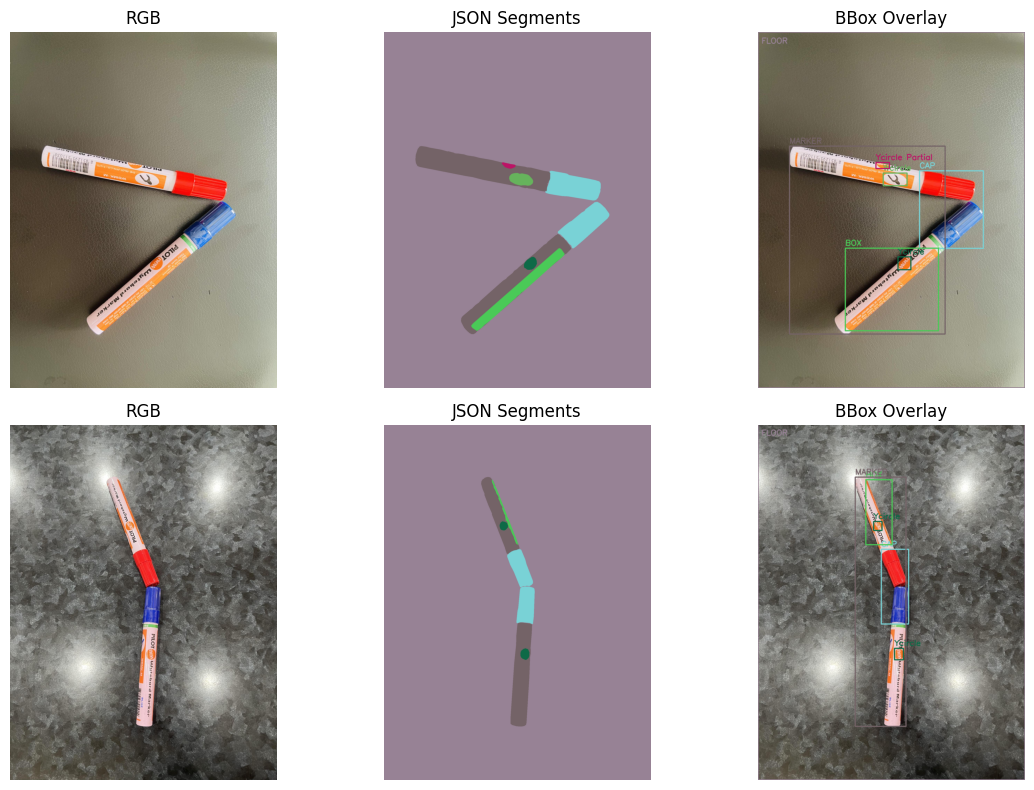

In [ ]:
import os
import json
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# PATHS
# -------------------------
IMG_DIR = "datasets/markerpenspansegv2/train/images"
MASK_DIR = "datasets/markerpenspansegv2/train/masks"
JSON_PATH = "datasets/markerpenspansegv2/train/panoptic_train_bg.json"

# -------------------------
# LOAD JSON
# -------------------------
with open(JSON_PATH, "r") as f:
    coco = json.load(f)

images = {img["id"]: img for img in coco["images"]}
annotations = coco["annotations"]
categories = {cat["id"]: cat for cat in coco["categories"]}

# -------------------------
# COLOR MAP (by category)
# -------------------------
np.random.seed(42)
color_map = {
    cat_id: np.random.randint(0, 255, size=3)
    for cat_id in categories.keys()
}

# -------------------------
# SAMPLE
# -------------------------
samples = random.sample(annotations, 2)

# -------------------------
# FUNCTION: build mask from JSON
# -------------------------
def build_mask_from_segments(panoptic, segments_info):
    h, w = panoptic.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    for seg in segments_info:
        seg_id = seg["id"]
        cat_id = seg["category_id"]

        mask = (panoptic == seg_id)

        if mask.sum() == 0:
            print(f"⚠️ Warning: segment {seg_id} missing in mask")

        out[mask] = color_map[cat_id]

    return out

# -------------------------
# PLOT
# -------------------------
fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4 * len(samples)))

if len(samples) == 1:
    axes = [axes]

for i, ann in enumerate(samples):
    img_info = images[ann["image_id"]]

    img_path = os.path.join(IMG_DIR, img_info["file_name"])
    mask_path = os.path.join(MASK_DIR, ann["file_name"])

    rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    panoptic = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    # JSON reconstruction
    json_mask = build_mask_from_segments(panoptic, ann["segments_info"])

    # -------------------------
    # DRAW BBOXES
    # -------------------------
    overlay = rgb.copy()

    for seg in ann["segments_info"]:
        x, y, w, h = seg["bbox"]
        cat_id = seg["category_id"]
        name = categories[cat_id]["name"]

        color = tuple(int(c) for c in color_map[cat_id])

        cv2.rectangle(
            overlay,
            (x, y),
            (x + w, y + h),
            color,
            5
        )

        if name != "FLOOR":
            cv2.putText(
                overlay,
                name,
                (x, y - 15),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.5,
                color,
                3,
                cv2.LINE_AA
            )
        else:
            cv2.putText(
                overlay,
                name,
                (x + 20, y + 65),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.5,
                color,
                3,
                cv2.LINE_AA
            )

    # -------------------------
    # SHOW
    # -------------------------
    axes[i][0].imshow(rgb)
    axes[i][0].set_title("RGB")
    axes[i][0].axis("off")

    axes[i][1].imshow(json_mask)
    axes[i][1].set_title("JSON Segments")
    axes[i][1].axis("off")

    axes[i][2].imshow(overlay)
    axes[i][2].set_title("BBox Overlay")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import json
import os
import cv2
import numpy as np
from PIL import Image
from pycocotools import mask as maskUtils

# ---- CONFIG ----
# panoptic_json_path = "datasets/markerpenspansegv2/train/panoptic_train.json"
# panoptic_root = "datasets/markerpenspansegv2/train/masksforjson"
# output_json_path = "datasets/markerpenspansegv2/train/instances_train.json"

panoptic_json_path = "datasets/markerpenspansegv2/valid/panoptic_val.json"
panoptic_root = "datasets/markerpenspansegv2/valid/masksforjson"
output_json_path = "datasets/markerpenspansegv2/valid/instances_val.json"

CATEGORIES = [
    {"id": 1, "name": "Wcircle", "isthing": 1},
    {"id": 2, "name": "Ycircle", "isthing": 1},
    {"id": 3, "name": "Ycircle Partial", "isthing": 1},
    {"id": 4, "name": "CAP", "isthing": 0},
    {"id": 5, "name": "BOX", "isthing": 0},
    {"id": 6, "name": "MARKER", "isthing": 0},
]

thing_ids = {c["id"] for c in CATEGORIES if c["isthing"] == 1}

# ---- LOAD PANOPTIC JSON ----
with open(panoptic_json_path) as f:
    panoptic_data = json.load(f)

images = panoptic_data["images"]
annotations = panoptic_data["annotations"]

instance_annotations = []
ann_id = 1

# ---- PROCESS ----
for ann in annotations:
    image_id = ann["image_id"]
    file_name = ann["file_name"]

    pan_path = os.path.join(panoptic_root, file_name)
    pan_mask = cv2.imread(pan_path, cv2.IMREAD_UNCHANGED).astype(np.int32)

    # print(np.unique(pan_mask)[:20])
    # print([seg["id"] for seg in ann["segments_info"][:10]])

    for seg in ann["segments_info"]:
        seg_id = seg["id"]

        # 🔥 derive category
        category_id = seg_id // 1000

        if category_id not in thing_ids:
            continue

        mask = (pan_mask == seg_id)

        if mask.sum() == 0:
            continue

        mask = mask.astype(np.uint8)
        mask = np.asfortranarray(mask)

        rle = maskUtils.encode(mask)
        rle["counts"] = rle["counts"].decode("ascii")

        # bbox from mask
        ys, xs = np.where(mask)
        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()

        bbox = [
            float(x_min),
            float(y_min),
            float(x_max - x_min + 1),
            float(y_max - y_min + 1),
        ]

        instance_annotations.append({
            "id": ann_id,
            "image_id": image_id,
            "category_id": category_id,
            "segmentation": rle,
            "bbox": bbox,
            "area": float(mask.sum()),
            "iscrowd": 0,
        })

        ann_id += 1

# ---- BUILD FINAL JSON ----
instance_json = {
    "images": images,
    "annotations": instance_annotations,
    "categories": [c for c in CATEGORIES if c["isthing"] == 1],
}

# ---- SAVE ----
with open(output_json_path, "w") as f:
    json.dump(instance_json, f)

print(f"Saved instance annotations to: {output_json_path}")
print(f"Total instances: {len(instance_annotations)}")

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


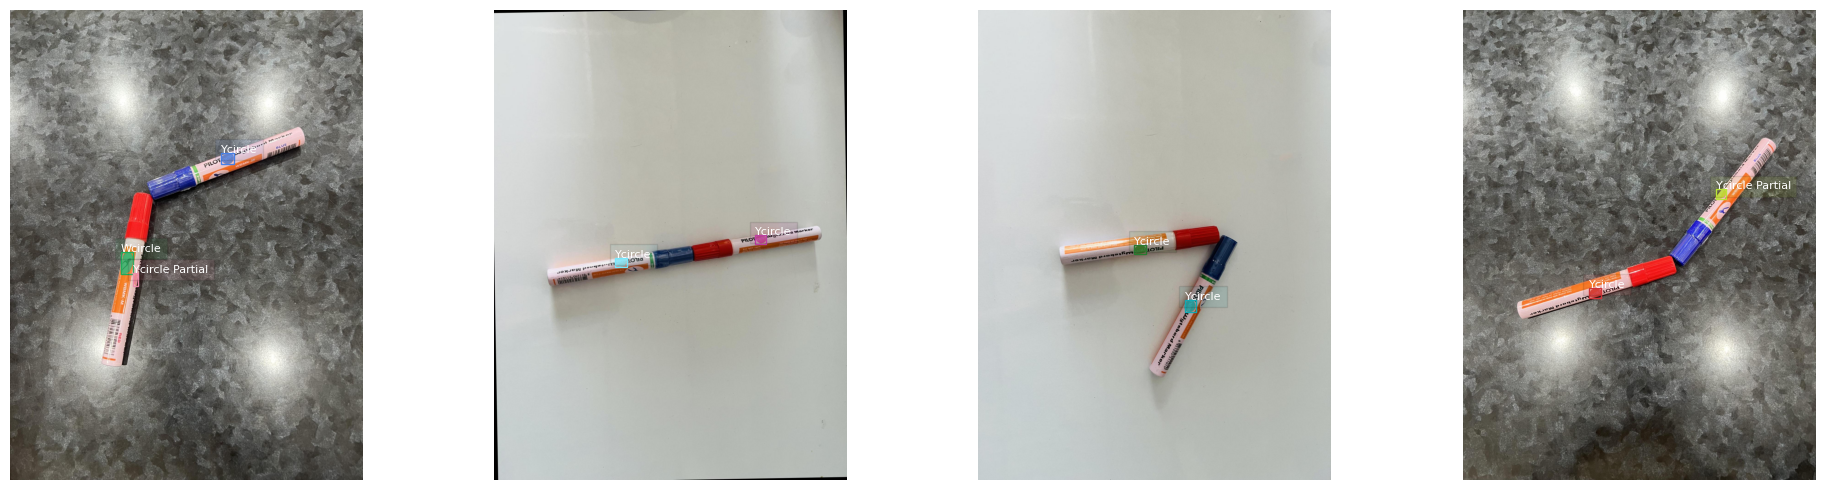

In [ ]:
import json
import random
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
from pycocotools import mask as maskUtils

# ---- PATHS ----
instance_json = "datasets/markerpenspansegv2/train/instances_train.json"
image_root = "datasets/markerpenspansegv2/train/images"
# instance_json = "datasets/markerpenspansegv2/valid/instances_val.json"
# image_root = "datasets/markerpenspansegv2/valid/images"

# ---- LOAD COCO ----
coco = COCO(instance_json)

# category id → name
cat_id_to_name = {cat["id"]: cat["name"] for cat in coco.loadCats(coco.getCatIds())}

# ---- RANDOM SAMPLE ----
img_ids = coco.getImgIds()
sample_ids = random.sample(img_ids, 4)

# ---- PLOT ----
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, img_id in zip(axes, sample_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(image_root, img_info["file_name"])

    image = np.array(Image.open(img_path).convert("RGB"))
    ax.imshow(image)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    overlay = image.copy().astype(np.float32) / 255.0

    for ann in anns:
        # decode mask
        rle = ann["segmentation"]
        mask = maskUtils.decode(rle)

        # random color
        color = np.random.rand(3)

        # overlay mask
        overlay[mask == 1] = overlay[mask == 1] * 0.2 + color * 0.8

        # bbox
        x, y, w, h = ann["bbox"]
        rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=1)
        ax.add_patch(rect)

        # label
        class_name = cat_id_to_name[ann["category_id"]]
        ax.text(x, y, class_name, color="white", fontsize=8,
                bbox=dict(facecolor=color, alpha=0.1))

    ax.imshow(overlay)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# =========================
# FUNCTION: ID → RGB
# =========================
def id_to_rgb(pan):
    r = pan % 256
    g = (pan // 256) % 256
    b = (pan // 256 // 256) % 256
    return np.stack([r, g, b], axis=2).astype(np.uint8)

# =========================
# CONVERT FUNCTION
# =========================
def convert_folder(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    files = [f for f in os.listdir(input_dir) if f.endswith(".png")]

    for file in tqdm(files):
        path = os.path.join(input_dir, file)

        pan = cv2.imread(path, cv2.IMREAD_UNCHANGED)

        if pan is None:
            print(f"❌ Failed to read {file}")
            continue

        # safety check
        if len(pan.shape) != 2:
            print(f"⚠️ Skipping (already RGB?): {file}")
            continue

        rgb = id_to_rgb(pan)

        cv2.imwrite(os.path.join(output_dir, file), rgb[:, :, ::-1])

    print(f"✅ Done: {output_dir}")

# =========================
# PATHS (EDIT IF NEEDED)
# =========================
train_in = "datasets/markerpenspansegv2/train/masks"
train_out = "datasets/markerpenspansegv2/train/panoptic_rgb_bg"

val_in = "datasets/markerpenspansegv2/valid/masks"
val_out = "datasets/markerpenspansegv2/valid/panoptic_rgb_bg"

# =========================
# RUN
# =========================
convert_folder(train_in, train_out)
convert_folder(val_in, val_out)

In [ ]:
!pip install git+https://github.com/cocodataset/panopticapi.git

In [4]:
from panopticapi.utils import rgb2id
from PIL import Image
import numpy as np

img = np.array(Image.open("datasets/markerpenspansegv2/train/panoptic_rgb_bg/74CF24FD-085D-46FE-8AB8-9FC26B2503C4_jpeg.rf.373a0a15852394edd8cd921d398d409b.png"))
ids = rgb2id(img)

print(np.unique(ids))

[1001 2001 3001 4000 5000 6000 7000]


In [ ]:
# STEP 1: Install compatible PyTorch (2.0.1 + CUDA 11.7)
!pip install torch==2.0.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# STEP 2: Install OpenMMLab tools
!pip install -U openmim
!mim install "mmengine>=0.7.4"
!mim install "mmcv==2.1.0"

# STEP 3: Clone MMDetection & install
!git clone https://github.com/open-mmlab/mmdetection.git
%cd mmdetection
!pip install -e .

In [2]:
# STEP 4: Final check
!python -c "import torch; import mmcv; import mmdet; print('PyTorch:', torch.__version__); print('MMCV:', mmcv.__version__); print('MMDet:', mmdet.__version__)"

PyTorch: 2.0.1+cu117
MMCV: 2.1.0
MMDet: 3.3.0


In [ ]:
!git clone https://github.com/open-mmlab/mmdeploy.git
%cd mmdeploy
!pip install -e .

In [4]:
!python -c "import mmdeploy; print('MMDeploy:', mmdeploy.__version__)"

MMDeploy: 1.3.1


In [ ]:
!pip install numpy==1.24.4

In [ ]:
import json
import os

def add_missing_info(file_path):
    """Adds a placeholder 'info' key to a COCO JSON file if missing."""
    if not os.path.exists(file_path):
        print(f"Error: {file_path} not found.")
        return

    with open(file_path, 'r') as f:
        data = json.load(f)

    if 'info' not in data:
        print(f"Adding 'info' key to {file_path}...")
        # Populate with standard COCO placeholders
        data['info'] = {
            "description": "Custom Dataset",
            "url": "",
            "version": "1.0",
            "year": 2024,
            "contributor": "User",
            "date_created": "2024/02/17"
        }

        with open(file_path, 'w') as f:
            json.dump(data, f, indent=4)
        print("Success!")
    else:
        print(f"'info' key already exists in {file_path}.")

# List all annotation files here
ann_files = [
    'datasets/markerpenspansegv2/train/instances_train.json',
    'datasets/markerpenspansegv2/valid/instances_val.json',
    'datasets/markerpenspansegv2/train/panoptic_train.json',
    'datasets/markerpenspansegv2/valid/panoptic_val.json'
]

for file in ann_files:
    add_missing_info(file)

'info' key already exists in datasets/markerpenspansegv2/train/instances_train.json.
'info' key already exists in datasets/markerpenspansegv2/valid/instances_val.json.
'info' key already exists in datasets/markerpenspansegv2/train/panoptic_train.json.
'info' key already exists in datasets/markerpenspansegv2/valid/panoptic_val.json.


In [ ]:
!ls mmdetection/configs/panoptic_fpn/

metafile.yml			     panoptic-fpn_r50_fpn_1x_coco.py
panoptic_fpn_pan_seg_marker.py	     panoptic-fpn_r50_fpn_ms-3x_coco.py
panoptic-fpn_r101_fpn_1x_coco.py     README.md
panoptic-fpn_r101_fpn_ms-3x_coco.py


In [ ]:
custom_cfg = """
_base_ = 'panoptic-fpn_r50_fpn_ms-3x_coco.py'

fixed_colors = [
    (255, 0, 0),
    (255, 255, 255),
    (0, 255, 255),
]
fixed_stuff_colors = [
    (0, 100, 0),
    (255, 200, 0),
    (128, 0, 255),
    (135, 206, 235),
]

# Custom classes
dataset_type = 'CocoPanopticDataset'
metainfo = dict(
    classes=("Wcircle", "Ycircle", "Ycircle Partial", "CAP", "BOX", "MARKER", "FLOOR"),
    thing_classes=("Wcircle", "Ycircle", "Ycircle Partial"),
    stuff_classes=("CAP", "BOX", "MARKER", "FLOOR"),
    # This specific mapping tells MMDetection that ID 1 = Wcircle, ID 7 = FLOOR, etc.
    categories=[
        {'id': 1, 'name': 'Wcircle', 'isthing': 1},
        {'id': 2, 'name': 'Ycircle', 'isthing': 1},
        {'id': 3, 'name': 'Ycircle Partial', 'isthing': 1},
        {'id': 4, 'name': 'CAP', 'isthing': 0},
        {'id': 5, 'name': 'BOX', 'isthing': 0},
        {'id': 6, 'name': 'MARKER', 'isthing': 0},
        {'id': 7, 'name': 'FLOOR', 'isthing': 0},
    ],
    palette=fixed_colors + fixed_stuff_colors,
)
num_things_classes = 3
num_stuff_classes = 4
num_classes = num_things_classes + num_stuff_classes

# Paths
data_root = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpenspansegv2/'
train_ann = data_root + 'train/instances_train.json'
val_ann = data_root + 'valid/instances_val.json'
train_img = data_root + 'train/images/'
val_img = data_root + 'valid/images/'
train_seg = data_root + 'train/panoptic_rgb_bg/'
val_seg = data_root + 'valid/panoptic_rgb_bg/'
train_pan = data_root + 'train/panoptic_train_bg.json'
val_pan = data_root + 'valid/panoptic_val_bg.json'

# Pipelines
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadPanopticAnnotations'),
    dict(type='Resize', scale=(512, 512), keep_ratio=False),
    dict(type='RandomFlip', prob=0.5),
    dict(type='Pad', size=(512, 512), pad_val=dict(img=(114, 114, 114))),
    dict(type='PackDetInputs')
]

test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='Resize', scale=(512, 512), keep_ratio=False),
    dict(type='Pad', size=(512, 512), pad_val=dict(img=(114, 114, 114))),
    dict(type='LoadPanopticAnnotations'),
    dict(
        type='PackDetInputs',
        meta_keys=('img_id', 'img_path', 'ori_shape', 'img_shape',
                   'scale_factor'))
]

# Data loader
train_dataloader = dict(
    batch_size=4,
    num_workers=2,
    persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=True),
    batch_sampler=dict(type='AspectRatioBatchSampler'),
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        ann_file=train_pan,
        data_prefix=dict(
            img=train_img, seg=train_seg),
        filter_cfg=dict(filter_empty_gt=True, min_size=32),
        pipeline=train_pipeline,
        metainfo=metainfo))

val_dataloader = dict(
    batch_size=4,
    num_workers=2,
    persistent_workers=True,
    drop_last=False,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(
        type=dataset_type,
        data_root=data_root,
        ann_file=val_pan,
        data_prefix=dict(img=val_img, seg=val_seg),
        test_mode=True,
        pipeline=test_pipeline,
        metainfo=metainfo))

test_dataloader = val_dataloader

# Evaluator
val_evaluator = [
    dict(type='CocoPanopticMetric', ann_file=val_pan, seg_prefix=val_seg),
    # dict(type='CocoMetric', ann_file=val_ann, metric=['bbox', 'segm'])
]

test_evaluator = val_evaluator

# Model
model = dict(
    type='PanopticFPN',
    data_preprocessor=dict(
        type='DetDataPreprocessor',
        mean=[123.675, 116.28, 103.53],
        std=[58.395, 57.12, 57.375],
        bgr_to_rgb=True,
        pad_size_divisor=32,
        pad_mask=True,
        mask_pad_value=0,
        pad_seg=True,
        seg_pad_value=255),
    roi_head=dict(
        bbox_head=dict(num_classes=num_things_classes),
        mask_head=dict(num_classes=num_things_classes)
    ),
    semantic_head=dict(
        type='PanopticFPNHead',
        num_things_classes=num_things_classes,
        num_stuff_classes=num_stuff_classes,
        in_channels=256,
        inner_channels=128,
        start_level=0,
        end_level=4,
        norm_cfg=dict(type='GN', num_groups=32, requires_grad=True),
        conv_cfg=None,
        loss_seg=dict(
            type='CrossEntropyLoss', ignore_index=255, loss_weight=0.5)),
    panoptic_fusion_head=dict(
        type='HeuristicFusionHead',
        num_things_classes=num_things_classes,
        num_stuff_classes=num_stuff_classes),
    test_cfg=dict(
        rcnn=dict(
            score_thr=0.6,
            nms=dict(type='nms', iou_threshold=0.5, class_agnostic=True),
            max_per_img=100,
            mask_thr_binary=0.5),
        # used in HeuristicFusionHead
        panoptic=dict(mask_overlap=0.5, stuff_area_limit=4096)))

# Schedule
train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=10, val_interval=1)
val_cfg = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

# Optimizer
optim_wrapper = dict(
    optimizer=dict(type='SGD', lr=0.01, momentum=0.9, weight_decay=0.0001),
    clip_grad=None
)

# learning rate
param_scheduler = [
    dict(
        type='LinearLR', start_factor=0.1, by_epoch=False, begin=0, end=50),
    dict(
        type='MultiStepLR',
        begin=0,
        end=10,
        by_epoch=True,
        milestones=[7, 9],
        gamma=0.1)
]

# Logging and checkpointing
default_hooks = dict(
    logger=dict(type='LoggerHook', interval=2),
    checkpoint=dict(type='CheckpointHook', interval=2)
)

# Output path
work_dir = '/content/gdrive/MyDrive/Pytorch-Models/mmdetection/mmdet_outputs/panoptic_fpn_pan_seg_marker'

# Load pretrained COCO model
load_from = 'https://download.openmmlab.com/mmdetection/v2.0/panoptic_fpn/panoptic_fpn_r50_fpn_mstrain_3x_coco/panoptic_fpn_r50_fpn_mstrain_3x_coco_20210824_171155-5650f98b.pth'
"""

with open('mmdetection/configs/panoptic_fpn/panoptic_fpn_pan_seg_marker.py', 'w') as f:
    f.write(custom_cfg)

In [ ]:
!python mmdetection/tools/train.py mmdetection/configs/panoptic_fpn/panoptic_fpn_pan_seg_marker.py --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
04/15 19:16:37 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1823235162
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA 

In [ ]:
!python mmdetection/tools/test.py mmdetection/configs/panoptic_fpn/panoptic_fpn_pan_seg_marker.py mmdetection/mmdet_outputs/panoptic_fpn_pan_seg_marker/epoch_10.pth

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
04/15 19:28:10 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 550212641
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA R

In [2]:
from mmdet.apis import init_detector, inference_detector
import mmcv

# Config and checkpoint paths
config_file = 'mmdetection/configs/panoptic_fpn/panoptic_fpn_pan_seg_marker.py'
checkpoint_file = 'mmdetection/mmdet_outputs/panoptic_fpn_pan_seg_marker/epoch_10.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

# Image path
img = 'datasets/markerpenspansegv2/valid/images/ECDAE56F-5BF4-45C0-A057-AE6CE1548973_jpeg.rf.608b0c25b37120d02c5a1543d4de2910.jpg'

# Run inference
result = inference_detector(model, img)
print(result)

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models/mmdetection/mmdet/models/losses/cross_entropy_loss.py:240: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


Loads checkpoint by local backend from path: mmdetection/mmdet_outputs/panoptic_fpn_pan_seg_marker/epoch_10.pth
<DetDataSample(

    META INFORMATION
    img_path: 'datasets/markerpenspansegv2/valid/images/ECDAE56F-5BF4-45C0-A057-AE6CE1548973_jpeg.rf.608b0c25b37120d02c5a1543d4de2910.jpg'
    img_shape: (512, 512)
    pad_shape: (512, 512)
    ori_shape: (2048, 1536)
    batch_input_shape: (512, 512)
    img_id: 0
    scale_factor: (0.3333333333333333, 0.25)

    DATA FIELDS
    pred_panoptic_seg: <PixelData(
        
            META INFORMATION
        
            DATA FIELDS
            sem_seg: tensor([[[6, 6, 6,  ..., 6, 6, 6],
                         [6, 6, 6,  ..., 6, 6, 6],
                         [6, 6, 6,  ..., 6, 6, 6],
                         ...,
                         [6, 6, 6,  ..., 6, 6, 6],
                         [6, 6, 6,  ..., 6, 6, 6],
                         [6, 6, 6,  ..., 6, 6, 6]]], device='cuda:0', dtype=torch.int32)
        ) at 0x7ce394730550>
    gt_

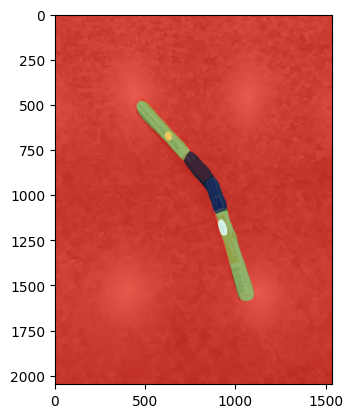

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import random
import os

# extract panoptic mask
pan_mask = result.pred_panoptic_seg.sem_seg.squeeze(0).cpu().numpy()  # shape HxW

# make safe palette
max_label = pan_mask.max() + 1
palette = np.random.randint(0, 255, size=(max_label, 3), dtype=np.uint8)
color_mask = palette[pan_mask]

# Load the image from the path before resizing
original_img = cv2.imread(img)
if original_img is None:
    raise Exception(f"Image not found or unreadable: {img}")

# resize original image to mask size
img_resized = cv2.resize(original_img, (pan_mask.shape[1], pan_mask.shape[0]))

# blend
vis = cv2.addWeighted(img_resized, 0.2, color_mask, 0.8, 0)

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.show()

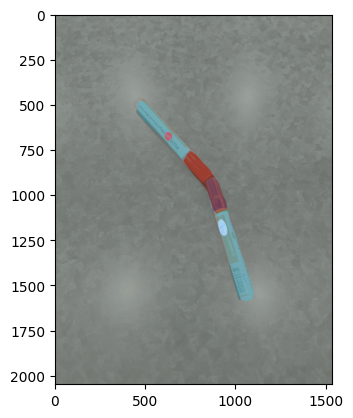

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import random
import os

# extract panoptic mask
pan_mask = result.pred_panoptic_seg.sem_seg.squeeze(0).cpu().numpy()  # shape HxW

# make safe palette
max_label = pan_mask.max() + 1
palette = np.random.randint(0, 255, size=(max_label, 3), dtype=np.uint8)
color_mask = palette[pan_mask]

# Load the image from the path before resizing
original_img = cv2.imread(img)
if original_img is None:
    raise Exception(f"Image not found or unreadable: {img}")

# resize original image to mask size
img_resized = cv2.resize(original_img, (pan_mask.shape[1], pan_mask.shape[0]))

# blend
vis = cv2.addWeighted(img_resized, 0.2, color_mask, 0.8, 0)

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.show()

In [ ]:
print(np.unique(pan_mask)[:20])

[   3    5    6 1001 2000]


In [3]:
from mmdet.registry import VISUALIZERS
import mmcv

def visualize_with_demo_pipeline(model, img_path):

    result = inference_detector(model, img_path)

    visualizer = VISUALIZERS.build(model.cfg.visualizer)
    visualizer.dataset_meta = model.dataset_meta

    img = mmcv.imread(img_path)
    img = mmcv.imconvert(img, 'bgr', 'rgb')

    visualizer.add_datasample(
        name='result',
        image=img,
        data_sample=result,
        draw_gt=False,
        show=False
    )

    vis_image = visualizer.get_image()

    return vis_image

(-0.5, 1535.5, 2047.5, -0.5)

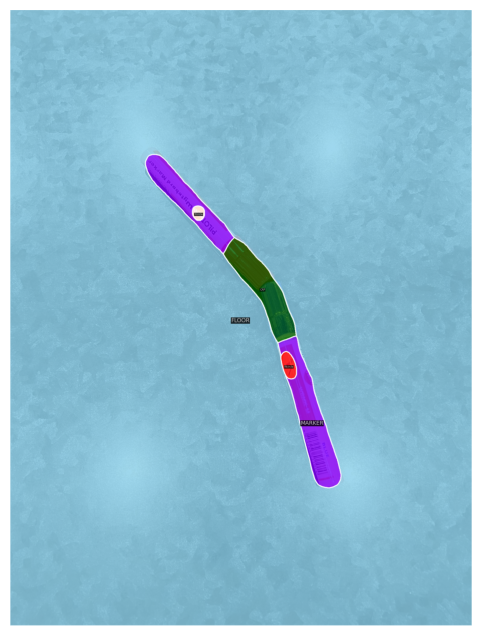

In [6]:
vis = visualize_with_demo_pipeline(model, img)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(vis)
plt.axis("off")

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import random
import os

In [13]:
@torch.no_grad()
def visualize_mmdet_panoptic_fpn(
    model,
    image_paths,
    num_images=3,
):
    import matplotlib.pyplot as plt
    import random
    import os
    import mmcv
    from mmdet.apis import inference_detector
    from mmdet.registry import VISUALIZERS

    model.eval()

    # -------------------------
    # IMAGE LIST
    # -------------------------
    all_imgs = [os.path.join(image_paths, f)
                for f in os.listdir(image_paths)
                if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    sample_imgs = random.sample(all_imgs, num_images)

    plt.figure(figsize=(6 * num_images, 6))

    # -------------------------
    # BUILD VISUALIZER ONCE
    # -------------------------
    visualizer = VISUALIZERS.build(model.cfg.visualizer)
    visualizer.dataset_meta = model.dataset_meta

    for idx, img_path in enumerate(sample_imgs):

        # -------------------------
        # INFERENCE
        # -------------------------
        result = inference_detector(model, img_path)

        # -------------------------
        # LOAD IMAGE
        # -------------------------
        img = mmcv.imread(img_path)
        img = mmcv.imconvert(img, 'bgr', 'rgb')

        # 🔥 IMPORTANT: match resolution
        pan_map = result.pred_panoptic_seg.sem_seg
        H, W = pan_map.shape[-2:]
        img = mmcv.imresize(img, (W, H))

        # -------------------------
        # DRAW (demo pipeline)
        # -------------------------
        visualizer.add_datasample(
            name='result',
            image=img,
            data_sample=result,
            draw_gt=False,
            show=False
        )

        vis = visualizer.get_image()

        # -------------------------
        # SHOW
        # -------------------------
        plt.subplot(1, num_images, idx + 1)
        plt.imshow(vis)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

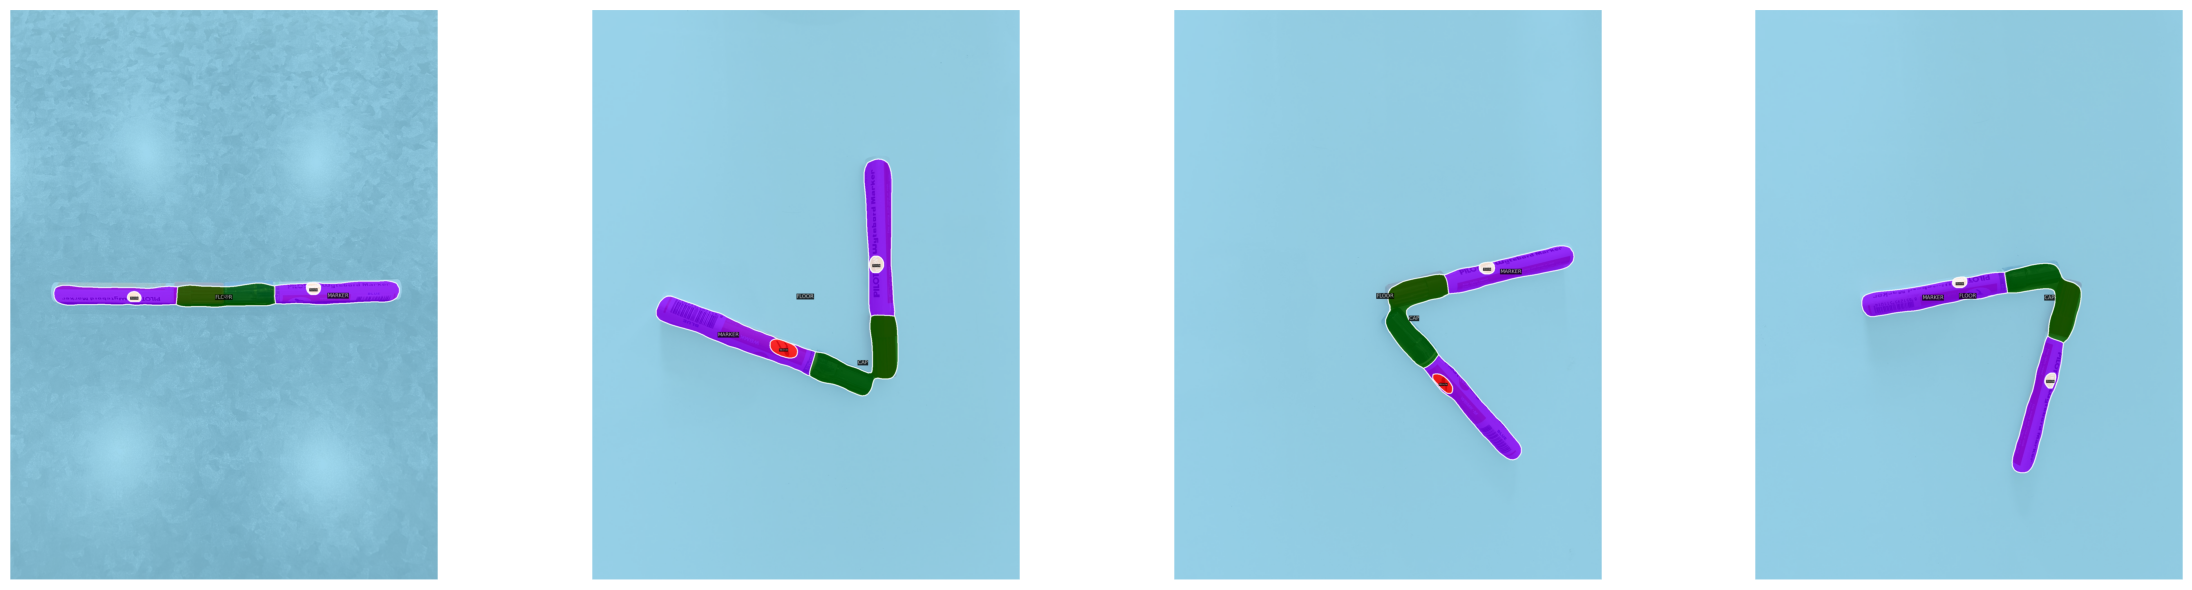

In [ ]:
visualize_mmdet_panoptic_fpn(
    model=model,
    image_paths="datasets/markerpenspansegv2/valid/images/",
    num_images=4)

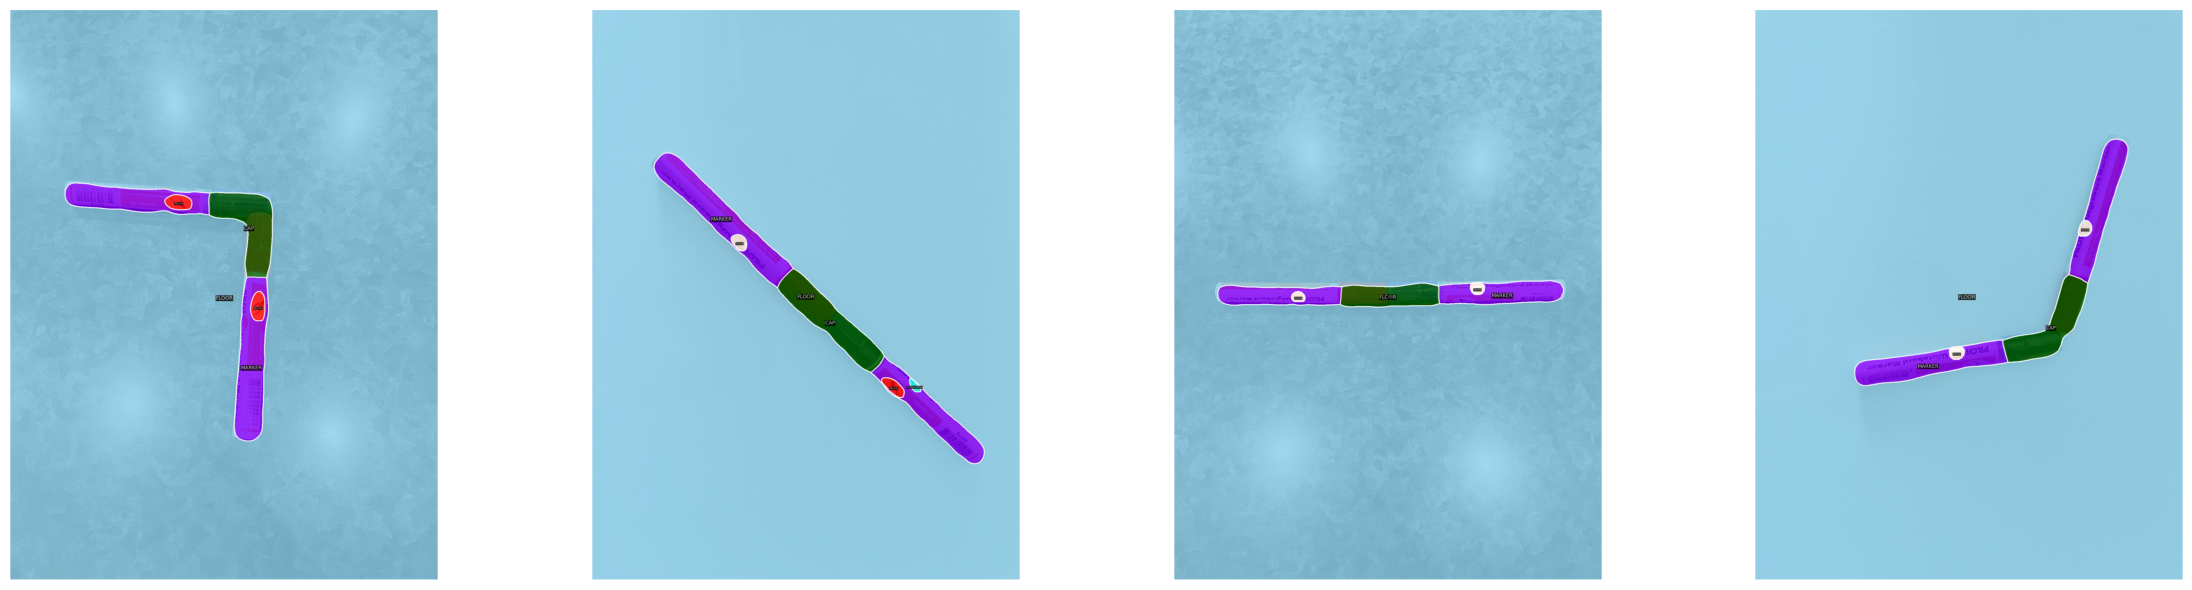

In [ ]:
visualize_mmdet_panoptic_fpn(
    model=model,
    image_paths="datasets/markerpenspansegv2/valid/images/",
    num_images=4)

In [14]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 97.1 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!=

In [15]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 7.4 MB/s eta 0:00:00


In [16]:
%ls mmdeploy/configs/mmdet/panoptic-seg/

panoptic-seg_maskformer_onnxruntime_dynamic.py
panoptic-seg_maskformer_onnxruntime_static-800x1344.py
panoptic-seg_maskformer_tensorrt_dynamic-320x512-1344x1344.py
panoptic-seg_maskformer_tensorrt_static-800x1344.py
panoptic-seg_panoptic-fpn_onnxruntime_dynamic.py
panoptic-seg_panoptic-fpn_tensorrt_dynamic-352x512-1344x1344.py


In [17]:
!python mmdeploy/tools/deploy.py \
    mmdeploy/configs/mmdet/panoptic-seg/panoptic-seg_panoptic-fpn_onnxruntime_dynamic.py \
    mmdetection/configs/panoptic_fpn/panoptic_fpn_pan_seg_marker.py \
    mmdetection/mmdet_outputs/panoptic_fpn_pan_seg_marker/epoch_10.pth \
    datasets/markerpenspansegv2/valid/images/ECDAE56F-5BF4-45C0-A057-AE6CE1548973_jpeg.rf.608b0c25b37120d02c5a1543d4de2910.jpg \
    --work-dir mmdeploy/mmdeploy_output/panoptic_fpn_pan_seg_marker/ \
    --device cpu \
    --dump-info

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
04/17 10:48:06 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "Codebases" registry tree. As a workaround, the current "Codebases" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
04/17 10:48:06 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "mmdet_tasks" registry tree. As a workaround, the current "mmdet_tasks" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
04/17 10:48:11 - mmengine - INFO - Start pipe

In [18]:
%ls mmdeploy/mmdeploy_output/panoptic_fpn_pan_seg_marker/

deploy.json  end2end.onnx            output_pytorch.jpg
detail.json  output_onnxruntime.jpg  pipeline.json


In [19]:
import onnxruntime
import numpy as np
import cv2
import torch
import os
import random

# Load image and preprocess
img_path = "datasets/markerpenspansegv2/valid/images/ECDAE56F-5BF4-45C0-A057-AE6CE1548973_jpeg.rf.608b0c25b37120d02c5a1543d4de2910.jpg"

mean = np.array([123.675, 116.28, 103.53], dtype=np.float32)
std = np.array([58.395, 57.12, 57.375], dtype=np.float32)

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (512, 512))
img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("mmdeploy/mmdeploy_output/panoptic_fpn_pan_seg_marker/end2end.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(1, 3, 5), (1, 3), (1, 3, 28, 28), (1, 5, 512, 512)]


In [27]:
for i, o in enumerate(outputs): print(f"Idx {i}: Max={o.max():.2f}, Min={o.min():.2f}, Shape={o.shape}")

Idx 0: Max=317.66, Min=0.00, Shape=(1, 3, 5)
Idx 1: Max=1.00, Min=0.00, Shape=(1, 3)
Idx 2: Max=1.00, Min=0.00, Shape=(1, 3, 28, 28)
Idx 3: Max=14.83, Min=-5.26, Shape=(1, 5, 512, 512)


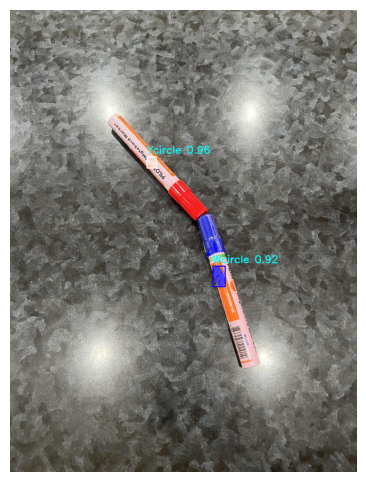

In [32]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

CLASS_LABELS = ['Wcircle', 'Ycircle', 'Ycircle-P']

class_colors = {
    'Wcircle': (255, 0, 0),
    'Ycircle': (255, 255, 255),
    'Ycircle-P': (0, 255, 255)}

# 1. Unpack outputs
# (1, 3, 5) -> boxes and scores
# (1, 3) -> labels
# (1, 3, 28, 28) -> raw mask logits
dets, labels, mask_logits = outputs[0][0], outputs[1][0], outputs[2][0]

orig_h, orig_w = img.shape[:2]
img_with_bbox = img.copy()

for i in range(len(dets)):
    box = dets[i, :4]
    score = dets[i, 4]
    label = int(labels[i])
    labeltext = CLASS_LABELS[label]

    if score < 0.5: # Threshold
        continue

    # --- Step A: Scale Box to Original Image ---
    x1 = int(box[0] * orig_w / 512)
    y1 = int(box[1] * orig_h / 512)
    x2 = int(box[2] * orig_w / 512)
    y2 = int(box[3] * orig_h / 512)

    # Clip coordinates to image boundaries
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(orig_w, x2), min(orig_h, y2)

    # --- Step B: Process the Mask ---
    # 1. Get the 28x28 mask for this object
    mask = mask_logits[i]

    # 2. Resize mask from 28x28 to the size of the bounding box
    box_w, box_h = x2 - x1, y2 - y1
    if box_w > 0 and box_h > 0:
        mask_resized = cv2.resize(mask, (box_w, box_h))

        # 3. Threshold the mask (0.5 is standard)
        mask_binary = (mask_resized > 0.5).astype(np.uint8)

        # 4. Create a random color for this mask
        # color = np.random.randint(0, 255, (3,)).tolist()
        color = class_colors[labeltext]

        # 5. Apply the mask as an overlay
        roi = img_with_bbox[y1:y2, x1:x2]
        # Paint the mask pixels
        roi[mask_binary == 1] = roi[mask_binary == 1] * 0.3 + np.array(color) * 0.7
        img_with_bbox[y1:y2, x1:x2] = roi

    # --- Step C: Draw Bounding Box and Label ---
    cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, 3)
    cv2.putText(img_with_bbox, f"{labeltext} {score:.2f}", (x1, y1 - 15),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

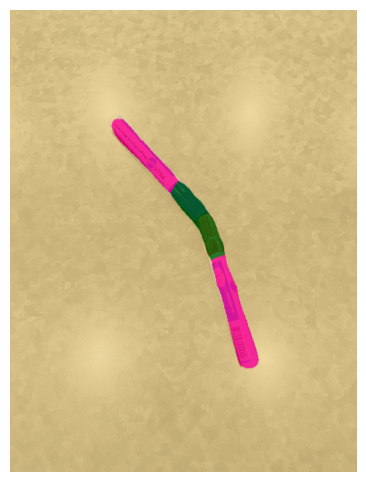

In [48]:
CATEGORY_COLORS = {
    0: (0, 100, 0),        # CAP
    1: (255, 200, 0),      # Box
    2: (128, 0, 255),      # Marker
    3: (135, 206, 235),    # Floor
}

orig_h, orig_w = img.shape[:2]

# 1. Create a color palette array (fast lookup)
palette_map = np.zeros((256, 3), dtype=np.uint8)
for i, color in CATEGORY_COLORS.items():
    palette_map[i] = color

# 2. Apply the colors in one vectorized step
mask = np.argmax(outputs[3].squeeze(), axis=0).astype(np.uint8)
color_mask = palette_map[mask] # Instant mapping

color_mask = cv2.resize(color_mask, (orig_w, orig_h))

# 3. Create a fast overlay
overlay = cv2.addWeighted(img[:, :, ::-1], 0.2, color_mask, 0.8, 0)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

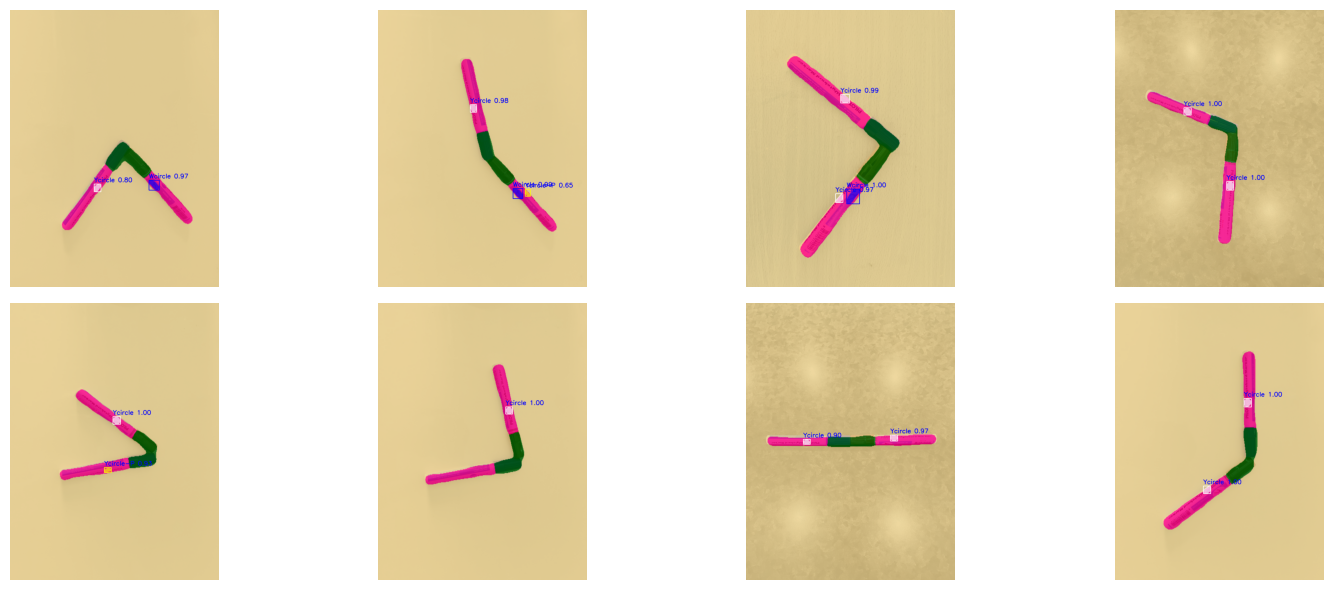

In [51]:
CONF_THR = 0.5

# ---------------- CONFIG ----------------
val_dir = "datasets/markerpenspansegv2/valid/images/"

CATEGORY_COLORS = {
    0: (0, 100, 0),        # CAP
    1: (255, 200, 0),      # Box
    2: (128, 0, 255),      # Marker
    3: (135, 206, 235),    # Floor
}
palette_map = np.zeros((256, 3), dtype=np.uint8)
for i, color in CATEGORY_COLORS.items():
    palette_map[i] = color

CLASS_LABELS = ['Wcircle', 'Ycircle', 'Ycircle-P']

class_colors = {
    'Wcircle': (255, 0, 0),
    'Ycircle': (255, 255, 255),
    'Ycircle-P': (0, 255, 255)}

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (512, 512))
    img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    orig_h, orig_w = img.shape[:2]

    mask = np.argmax(outputs[3].squeeze(), axis=0).astype(np.uint8)
    color_mask = palette_map[mask]

    color_mask = cv2.resize(color_mask, (orig_w, orig_h))
    overlay = cv2.addWeighted(img[:, :, ::-1], 0.2, color_mask, 0.8, 0)

    dets, labels, mask_logits = outputs[0][0], outputs[1][0], outputs[2][0]

    img_with_bbox = overlay.copy()

    for i in range(len(dets)):
        box = dets[i, :4]
        score = dets[i, 4]
        label = int(labels[i])
        labeltext = CLASS_LABELS[label]

        if score < CONF_THR: # Threshold
            continue

        x1 = int(box[0] * orig_w / 512)
        y1 = int(box[1] * orig_h / 512)
        x2 = int(box[2] * orig_w / 512)
        y2 = int(box[3] * orig_h / 512)

        # Clip coordinates to image boundaries
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(orig_w, x2), min(orig_h, y2)

        mask = mask_logits[i]

        box_w, box_h = x2 - x1, y2 - y1
        if box_w > 0 and box_h > 0:
            mask_resized = cv2.resize(mask, (box_w, box_h))
            mask_binary = (mask_resized > 0.5).astype(np.uint8)

            color = class_colors[labeltext]
            roi = img_with_bbox[y1:y2, x1:x2]

            roi[mask_binary == 1] = roi[mask_binary == 1] * 0.3 + np.array(color) * 0.7
            img_with_bbox[y1:y2, x1:x2] = roi

        cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img_with_bbox, f"{labeltext} {score:.2f}", (x1, y1 - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 3)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()